# Job outcome modeling

Every prediction here is constrained to the information available **at the moment it would be
made**, so the model can never read a feature that is only knowable after the outcome it is
predicting.

**Two groups, two feature sets, two training sets:**

- **Match-time group** — `Failed`, and `hw_fault` (Hardware/infrastructure vs Payload/user, among
  failures). Application vs Submission is inseparable at match time (68% of campaigns emit both, so
  their features are identical and only the exit code — the label — distinguishes them), so the
  predictive failure-type target is the separable Hardware-vs-Payload split, which the paper frames
  as systemic-bottleneck vs user-error. Both tasks fire once a job has matched, so they use
  everything known at submission *plus* match-time context: matched site / entry / resource / node,
  provisioned resources, execution-start cyclical time, running-concurrency, and leak-free trailing
  **site/entry/node health** (1m/5m/1h windows) — what lets Hardware be captured.
- **Submission-time group** — `wait_time` (regression). Fires when the job enters the queue,
  before any match, so it uses submission-known features only (requested resources,
  campaign/image identity, submission-clock cyclical time, leak-free trailing campaign fail/hold
  rates and **mean queue-wait**, and a leak-free **queue-depth-at-submit** feature).

The hold-prediction tasks (`problem_hold`, `hold_type`) are out of scope in this notebook; the
recent hold rate is retained only as a trailing *feature* for failure prediction. `Drain` is
dropped: it is leakage-shaped missingness (its null value is a fingerprint of an abnormal run,
failing 51% vs 17.7%) — see the audit cell below.

**Deliberately excluded everywhere** (leakage, established in the analysis notebook): `JobStatus`,
`LastHoldReasonCode`, `JobPrio`, `JobCurrentWaitTime` (it bakes in post-hold requeue time), and
month-of-year cyclical features (a within-period memorization crutch that does not generalize).

**Trailing state features** are the leak-free replacement for raw node/site identity: for each job,
the failure/hold rate over jobs of the same key that *completed strictly before this job's
reference time* (submission time for the submission group, execution start for the match group),
within a rolling window. The helper is brute-force validated below, including explicit
self-exclusion so a job can never see its own outcome even under data-clock quirks.

In [1]:
%%time
import os, gc, math
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")
DATA = "/Users/allison/Documents/Github/fife-batch-jobs/data"
FILES = [f"{DATA}/processed_job_data_0{m}.parquet" for m in range(1, 7)]
MODELS_DIR = "../models/staged"
os.makedirs(MODELS_DIR, exist_ok=True)
SUBSET_FRACTION = 0.20
TRAIN_MONTHS, TEST_MONTHS = [1, 2, 3, 4], [5, 6]

PAL_MODEL = {"xgboost": "#0072B2", "lightgbm": "#E69F00", "catboost": "#009E73"}
MODEL_ORDER = ["xgboost", "lightgbm", "catboost"]
FTYPE_NAMES = ["Application", "Hardware", "Submission"]
HOLD_NAMES = ["memory/disk limit", "runtime limit", "spooling input", "other policy"]

CPU times: user 864 ms, sys: 132 ms, total: 996 ms
Wall time: 1.14 s


In [2]:
%%time
LABEL_COLS = ["ExitCode", "ExitSignal", "JobStatus", "LastHoldReasonCode", "LastHoldReason",
              "RemoveReason", "QDate_ms", "JobCurrentStartExecutingDate_ms", "JobStartDate_ms",
              "CompletionDate_ms", "RemoteWallClockTime", "x509UserProxyExpiration_ms"]
SUB_CAT = ["Group", "Owner", "POMS_LAUNCHER", "POMS4_CAMPAIGN_NAME", "POMS4_CAMPAIGN_STAGE_NAME",
           "POMS4_CAMPAIGN_ID", "POMS4_CAMPAIGN_STAGE_ID", "POMS4_CAMPAIGN_TYPE",
           "POMS4_TEST_LAUNCH", "Jobsub_Group", "SingularityImage", "Blacklist_Sites"]
SUB_NUM = ["RequestCpus", "RequestDisk", "RequestMemory", "RequestSlots", "ExecutableSize",
           "TransferInputSizeMB", "JOB_EXPECTED_MAX_LIFETIME", "TotalSubmitProcs"]
MATCH_CAT = ["MATCH_EXP_JOB_GLIDEIN_Site", "MATCH_GLIDEIN_Entry_Name", "MATCH_GLIDEIN_SiteWMS_Queue",
             "MachineAttrGLIDEIN_ResourceName0", "MachineAttrCpus0"]  # Drain dropped: leakage-shaped missingness
MATCH_NUM = ["CpusProvisioned", "DiskProvisioned", "MemoryProvisioned"]
KEY_COLS = ["MATCH_EXP_JOB_Site", "LastRemoteHost"]
need = list(dict.fromkeys(LABEL_COLS + SUB_CAT + SUB_NUM + MATCH_CAT + MATCH_NUM + KEY_COLS))

df = pl.concat([pl.read_parquet(f, columns=need) for f in FILES], how="vertical")
print(f"loaded {df.height:,} jobs")

# --- outcome flags ---
failed = ((pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0))
          | pl.col("ExitSignal").is_not_null() | (pl.col("JobStatus") == 3)).cast(pl.Int8)
# failure_type: 0 Application, 1 Hardware, 2 Submission, -1 excluded (README cascade)
EXIT_SUB = [9, 65, 90, 91, 124, 126, 127, 130, 131, 137]; EXIT_HW = [129, 143]
SIG_SUB = [2, 3, 9]; SIG_HW = [1, 15]
HOLD_APP = [3, 6, 16]; HOLD_SUB = [1, 4, 7, 8, 12, 13, 26, 32, 33, 34, 35]
rr = pl.col("RemoveReason").fill_null(""); lhr = pl.col("LastHoldReasonCode")
ftype = (pl.when((pl.col("ExitCode") == 0) & pl.col("ExitSignal").is_null() & (pl.col("JobStatus") != 3)).then(-1)
         .when(pl.col("ExitSignal").is_in(SIG_SUB)).then(2).when(pl.col("ExitSignal").is_in(SIG_HW)).then(1)
         .when(pl.col("ExitSignal").is_not_null()).then(0)
         .when(pl.col("ExitCode").is_in(EXIT_SUB)).then(2).when(pl.col("ExitCode").is_in(EXIT_HW)).then(1)
         .when(pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0)).then(0)
         .when(lhr.is_in(HOLD_APP)).then(0).when(lhr.is_in(HOLD_SUB)).then(2)
         .when(rr.str.contains("OtherJobRemoveRequirements") | rr.str.contains("Node Error: DAG node")).then(0)
         .when(rr.str.contains("exceeding job limits") | rr.str.contains("opportunistic")).then(2)
         .when(rr.str.contains("Held 14 days") | rr.str.contains("PeriodicRemove")).then(0)
         .when(rr.str.contains("JobRouter")).then(1)
         .when(rr.str.contains(r"via condor_rm \(by user")).then(-1)
         .when(pl.col("JobStatus") == 3).then(1).otherwise(-1)).cast(pl.Int8)
# problem_hold: held with a non-benign code (excl 16 spool / 1 manual / 12 output-transfer / null)
prob_hold = pl.when(lhr.is_null() | lhr.is_in([16, 1, 12])).then(0).otherwise(1).cast(pl.Int8)
# hold_type (submission-time target). 4 classes: 0 memory/disk, 1 runtime, 2 spooling input
# (benign lifecycle, code 16), 3 other policy (95% code-26 "Shadows/limit" restart-budget
# exhaustion + code-3 PeriodicHold). Excluded: node failure (6/35, unknowable at submission),
# manual user hold (1), output-transfer hold (12, a downstream symptom of failure).
lhr_txt = pl.col("LastHoldReason").fill_null("").str.to_lowercase()
htype = (pl.when(lhr.is_null() | lhr.is_in([1, 12, 6, 35])).then(-1)
         .when(lhr == 16).then(2)
         .when(lhr == 34).then(0)
         .when((lhr == 26) & lhr_txt.str.contains("run ?time")).then(1)
         .when((lhr == 26) & lhr_txt.str.contains("memory|disk")).then(0)
         .otherwise(3)).cast(pl.Int8)
# wait_time target: first-start minus submit, seconds (leak-free: known once it starts)
wait_s = ((pl.col("JobStartDate_ms") - pl.col("QDate_ms")) / 1000.0)

df = df.with_columns([
    failed.alias("Failed"),
    ftype.alias("failure_type"),
    prob_hold.alias("problem_hold"),
    htype.alias("hold_type"),
    pl.when(wait_s > 0).then(wait_s).otherwise(None).alias("wait_s"),
    pl.from_epoch(pl.col("QDate_ms"), time_unit="ms").dt.month().alias("qmonth"),
])
df = df.with_columns((pl.col("failure_type") == 1).cast(pl.Int8).alias("hw_fault"))
print("failure_type:", df.group_by("failure_type").len().sort("failure_type").to_dicts())
print("hold_type:   ", df.group_by("hold_type").len().sort("hold_type").to_dicts())

loaded 41,079,913 jobs


failure_type: [{'failure_type': -1, 'len': 33403996}, {'failure_type': 0, 'len': 5148227}, {'failure_type': 1, 'len': 1254580}, {'failure_type': 2, 'len': 1273110}]
hold_type:    [{'hold_type': -1, 'len': 18172572}, {'hold_type': 0, 'len': 1299768}, {'hold_type': 1, 'len': 290604}, {'hold_type': 2, 'len': 20925783}, {'hold_type': 3, 'len': 391186}]
CPU times: user 14.9 s, sys: 3.21 s, total: 18.1 s
Wall time: 2.13 s


In [3]:
%%time
# proxy lifetime remaining at submit (hours), clipped; stage_type from campaign stage name
df = df.with_columns(
    ((pl.col("x509UserProxyExpiration_ms") - pl.col("QDate_ms")) / 3.6e6).clip(-720, 720)
    .alias("proxy_hours_left"))
_lc = pl.col("POMS4_CAMPAIGN_STAGE_NAME").str.to_lowercase()
df = df.with_columns(
    pl.when(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null() & pl.col("POMS4_CAMPAIGN_NAME").is_null())
      .then(pl.lit(None, dtype=pl.Utf8))
    .when(_lc.str.contains("gen|g4|sim|dio|endpoint|corsika|resample|wire_mod|wiremod|ly_|lyattn|"
                           "lydown|sce|theta|tpc|offset|mix|ensemble|rpc|spill|cv|run[0-9]+")).then(pl.lit("generation"))
    .when(_lc.str.contains("reco|track|stage0|stage1|digi|decode|recluster|fullproduction|ndlar|compress|convert")).then(pl.lit("reconstruction"))
    .when(_lc.str.contains("merge|skim|hadd|filter|scrub|watchdog|sleep|test|fclless")).then(pl.lit("merging"))
    .when(_lc.str.contains("ana|caf|ntuple|larcv")).then(pl.lit("analysis"))
    .otherwise(pl.lit("other_production")).alias("stage_type"))

# cyclical time for both clocks, WITHOUT month (submission clock -> submission family;
# execution-start clock -> match family). month dropped: harmful out-of-time.
def cyc(col, period, pfx):
    return [(2*math.pi*col/period).sin().alias(f"{pfx}_sin"),
            (2*math.pi*col/period).cos().alias(f"{pfx}_cos")]
exprs = []
for src, tag in [("QDate_ms", "qdate"), ("JobCurrentStartExecutingDate_ms", "jstart")]:
    dt = pl.from_epoch(pl.col(src), time_unit="ms")
    exprs += cyc(dt.dt.hour(), 24, f"{tag}_hour") + cyc(dt.dt.weekday(), 7, f"{tag}_dow") + cyc(dt.dt.day(), 31, f"{tag}_dom")
df = df.with_columns(exprs)
SUB_CYC = [f"qdate_{p}_{t}" for p in ["hour", "dow", "dom"] for t in ["sin", "cos"]]
MATCH_CYC = [f"jstart_{p}_{t}" for p in ["hour", "dow", "dom"] for t in ["sin", "cos"]]

# running concurrency at start (match family), same validated event-sweep as before
end_ms = pl.max_horizontal(pl.col("CompletionDate_ms"),
                           pl.col("JobCurrentStartExecutingDate_ms") + pl.col("RemoteWallClockTime")*1000)
df = df.with_row_index("rid").with_columns(
    pl.when(end_ms > pl.col("JobCurrentStartExecutingDate_ms")).then(end_ms)
      .otherwise(pl.col("JobCurrentStartExecutingDate_ms") + 1).alias("end_ms"))

def running_count(d, key, out):
    dd = d.filter(pl.col(key).is_not_null() & pl.col("JobCurrentStartExecutingDate_ms").is_not_null())
    ev = pl.concat([
        dd.select(pl.col(key).alias("k"), pl.col("JobCurrentStartExecutingDate_ms").alias("t"), pl.lit(1).alias("delta"), pl.lit(0).alias("ok")),
        dd.select(pl.col(key).alias("k"), pl.col("end_ms").alias("t"), pl.lit(-1).alias("delta"), pl.lit(1).alias("ok")),
    ]).sort(["k", "t", "ok"], descending=[False, False, True])
    ev = ev.with_columns(pl.col("delta").cum_sum().over("k").alias("r"))
    ev = ev.group_by("k", "t", maintain_order=True).agg(pl.col("r").last()).sort("t")
    out_df = (d.select("rid", pl.col(key).alias("k"), pl.col("JobCurrentStartExecutingDate_ms").alias("t")).sort("t")
                .join_asof(ev, on="t", by="k", strategy="backward"))
    own = (pl.col("k").is_not_null() & pl.col("t").is_not_null()).cast(pl.Int32)
    return out_df.with_columns((pl.col("r").fill_null(0) - own).alias(out)).select("rid", out)

CONC = ["conc_running_same_site", "conc_running_same_group"]
for key, name in [("MATCH_EXP_JOB_Site", CONC[0]), ("Group", CONC[1])]:
    df = df.join(running_count(df, key, name), on="rid", how="left")
df = df.with_columns([pl.col(c).fill_null(0) for c in CONC])
print("derived features done")

<timed exec>:45: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


derived features done
CPU times: user 1min 58s, sys: 52.7 s, total: 2min 50s
Wall time: 36.4 s


### Missingness-vs-failure audit

`Drain` turned out to be leakage-shaped: it had only `false`/null values, and *null* meant a 51%
failure rate vs 17.7% for `false` — the attribute goes missing precisely when the run was
abnormal, so its null is a fingerprint of the outcome. This cell screens every candidate feature
the same way: null rate, and the failure rate among null vs non-null rows. A feature whose
`null` rows fail far more than its populated rows is a missingness-leak suspect and should be
dropped or its null-indicator excluded (as we did for `Drain`).

In [4]:
%%time
base_rate = df["Failed"].mean()
audit = []
for c in SUB_CAT + SUB_NUM + MATCH_CAT + MATCH_NUM:
    isnull = pl.col(c).is_null()
    g = df.select([isnull.alias("nz"), pl.col("Failed")]).group_by("nz").agg(
        pl.len().alias("n"), pl.col("Failed").mean().alias("fr"))
    d = {r["nz"]: (r["n"], r["fr"]) for r in g.iter_rows(named=True)}
    n_null, fr_null = d.get(True, (0, float("nan")))
    n_ok, fr_ok = d.get(False, (0, float("nan")))
    if n_null > 0:
        audit.append({"feature": c, "null_pct": 100*n_null/df.height,
                      "fail_rate_null": fr_null, "fail_rate_populated": fr_ok,
                      "gap": (fr_null - fr_ok) if fr_ok == fr_ok else float("nan")})
aud = pd.DataFrame(audit).sort_values("gap", ascending=False, key=lambda s: s.abs())
pd.set_option("display.width", 200)
print(f"overall failure rate: {base_rate:.3f}")
print("features with any nulls, ranked by |failure-rate gap between null and populated rows|:")
print(aud.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\n>> large positive gap = null predicts failure = missingness-leak suspect "
      "(Drain already dropped).")

overall failure rate: 0.187
features with any nulls, ranked by |failure-rate gap between null and populated rows|:
                         feature  null_pct  fail_rate_null  fail_rate_populated    gap
                MachineAttrCpus0     0.002           1.000                0.187  0.813
                           Group     0.000           0.931                0.187  0.744
                 DiskProvisioned     0.000           0.750                0.187  0.563
                 CpusProvisioned     0.000           0.750                0.187  0.563
               MemoryProvisioned     0.000           0.750                0.187  0.563
                    Jobsub_Group     2.325           0.499                0.179  0.319
      MATCH_EXP_JOB_GLIDEIN_Site     2.325           0.499                0.179  0.319
        MATCH_GLIDEIN_Entry_Name     2.325           0.499                0.179  0.319
     MATCH_GLIDEIN_SiteWMS_Queue     2.325           0.499                0.179  0.319
MachineAttrGLID

In [5]:
%%time
sub = df.sample(fraction=SUBSET_FRACTION, seed=42)
print(f"subset: {sub.height:,} jobs")
del df; gc.collect()


def trailing_rate(key_codes, tref, tcomp, outcome, is_comp, window):
    """Leak-free trailing rate + count. Rate of `outcome` over same-key jobs that COMPLETED in
    (tref-window, tref]; the job's own completion is explicitly excluded. Brute-force validated."""
    n = len(key_codes)
    ssum = np.zeros(n); cnt = np.zeros(n, dtype=np.int64)
    ci = np.where(is_comp)[0]
    ck, ct, co = key_codes[ci], tcomp[ci], outcome[ci].astype(np.float64)
    o = np.lexsort((ct, ck)); ck, ct, co = ck[o], ct[o], co[o]
    csum = np.concatenate([[0.0], np.cumsum(co)])
    uc, cs0 = np.unique(ck, return_index=True); ce0 = np.append(cs0[1:], len(ck))
    seg = {k: (cs0[i], ce0[i]) for i, k in enumerate(uc)}
    qo = np.argsort(key_codes, kind="stable"); qk, qt = key_codes[qo], tref[qo]
    uq, qs0 = np.unique(qk, return_index=True); qe0 = np.append(qs0[1:], n)
    for i, k in enumerate(uq):
        s = seg.get(k)
        if s is None:
            continue
        a, b = s; Ck = ct[a:b]; times = qt[qs0[i]:qe0[i]]
        hi = a + np.searchsorted(Ck, times, side="right")
        lo = a + np.searchsorted(Ck, times - window, side="right")
        rows = qo[qs0[i]:qe0[i]]; cnt[rows] = hi - lo; ssum[rows] = csum[hi] - csum[lo]
    self_in = is_comp & ~np.isnan(tref) & (tcomp <= tref) & (tcomp > tref - window)
    ssum[self_in] -= outcome[self_in]; cnt[self_in] -= 1
    with np.errstate(invalid="ignore", divide="ignore"):
        rate = np.where(cnt > 0, ssum / np.maximum(cnt, 1), np.nan)
    return rate.astype(np.float32), cnt.astype(np.float32)


S15, S30, M1, M5, M15, M30, H1, H6 = (15*1000, 30*1000, 60*1000, 5*60*1000, 15*60*1000,
                                      30*60*1000, 3600*1000, 6*3600*1000)
tcomp = sub["CompletionDate_ms"].cast(pl.Float64).to_numpy()       # when fail/hold outcome is known
tstart = sub["JobStartDate_ms"].cast(pl.Float64).to_numpy()        # when queue-wait becomes known
q_sub = sub["QDate_ms"].cast(pl.Float64).to_numpy()
q_mat = sub["JobCurrentStartExecutingDate_ms"].cast(pl.Float64).to_numpy()
out_fail = sub["Failed"].to_numpy(); out_hold = sub["problem_hold"].to_numpy(); out_hw = sub["hw_fault"].to_numpy()
wait_log_out = np.log1p(sub["wait_s"].cast(pl.Float64).to_numpy())  # continuous outcome for wait-mean
comp_ok = ~np.isnan(tcomp)
wait_ok = ~np.isnan(tstart) & ~np.isnan(wait_log_out)


def kcodes(colname):
    return sub[colname].cast(pl.Utf8).fill_null("__NA__").cast(pl.Categorical).to_physical().to_numpy()

# submission-time trailing (reference = QDate); keys knowable at submit. Campaign only
# (owner/group dropped per experiment design).
SUB_TRAIL = {}
for nm, keycol, out, win in [("camp_fail_1h", "POMS4_CAMPAIGN_ID", out_fail, H1),
                             ("camp_hold_1h", "POMS4_CAMPAIGN_ID", out_hold, H1)]:
    r, _ = trailing_rate(kcodes(keycol), q_sub, tcomp, out, comp_ok, win)
    SUB_TRAIL[nm] = r
# submission-time trailing MEAN queue-wait (campaign), leak-free (wait known only at start)
r, _ = trailing_rate(kcodes("POMS4_CAMPAIGN_ID"), q_sub, tstart, wait_log_out, wait_ok, H6)
SUB_TRAIL["camp_waitmean_6h"] = r
# queue-state proxy: global idle queue depth at submit = jobs submitted-but-not-yet-started at t.
qd_sorted = np.sort(q_sub[~np.isnan(q_sub)]); js_sorted = np.sort(tstart[~np.isnan(tstart)])
SUB_TRAIL["idle_queue_depth"] = (np.searchsorted(qd_sorted, q_sub, "right")
                                 - np.searchsorted(js_sorted, q_sub, "right")).astype(np.float32)

# match-time trailing (reference = execution start); keys = site / entry / node only.
# Windows trimmed to the ones that carried gain last run: 1m/5m (workhorses) + 1h anchor on the
# dense site/entry keys; node (~57k, sparse) gets 15m/1h. 15s/30s and 15m/30m were ~0 importance.
q_mat_f = np.where(np.isnan(q_mat), -1e18, q_mat)
MATCH_TRAIL = {}
SITE, ENTRY, NODE = "MATCH_EXP_JOB_GLIDEIN_Site", "MATCH_GLIDEIN_Entry_Name", "LastRemoteHost"
LADDER = ([(f"site_fail_{tag}", SITE, out_fail, w) for tag, w in [("1m", M1), ("5m", M5), ("1h", H1)]]
          + [("site_hold_5m", SITE, out_hold, M5), ("site_hw_1h", SITE, out_hw, H1)]
          + [(f"entry_fail_{tag}", ENTRY, out_fail, w) for tag, w in [("1m", M1), ("5m", M5), ("1h", H1)]]
          + [("node_fail_15m", NODE, out_fail, M15), ("node_fail_1h", NODE, out_fail, H1),
             ("node_hw_1h", NODE, out_hw, H1)])
for nm, keycol, out, win in LADDER:
    r, c = trailing_rate(kcodes(keycol), q_mat_f, tcomp, out, comp_ok, win)
    r[np.isnan(q_mat)] = np.nan          # unmatched jobs have no match-time context
    MATCH_TRAIL[nm] = r
SUB_TRAIL_COLS, MATCH_TRAIL_COLS = list(SUB_TRAIL), list(MATCH_TRAIL)
cov = 100*np.mean(~np.isnan(SUB_TRAIL["camp_fail_1h"]))
print(f"trailing features built ({len(SUB_TRAIL)} submission + {len(MATCH_TRAIL)} match). "
      f"camp_fail_1h coverage {cov:.1f}%; mean site_fail_1m {np.nanmean(MATCH_TRAIL['site_fail_1m']):.3f}; "
      f"mean camp_waitmean_6h {np.nanmean(SUB_TRAIL['camp_waitmean_6h']):.2f}")

subset: 8,215,982 jobs


trailing features built (4 submission + 11 match). camp_fail_1h coverage 95.1%; mean site_fail_1m 0.141; mean camp_waitmean_6h 6.88
CPU times: user 2min 15s, sys: 19.7 s, total: 2min 34s
Wall time: 2min 19s


In [6]:
%%time
CAT_ALL = SUB_CAT + MATCH_CAT
enc = sub.select(
    [pl.col(c).cast(pl.Utf8).fill_null("__MISSING__").cast(pl.Categorical).to_physical().cast(pl.Float32).alias(c) for c in CAT_ALL]
    + [pl.col(c).cast(pl.Float32, strict=False).alias(c) for c in SUB_NUM + MATCH_NUM + SUB_CYC + MATCH_CYC + CONC])
E = {c: enc[c].to_numpy() for c in enc.columns}
E.update(SUB_TRAIL); E.update(MATCH_TRAIL)
del enc; gc.collect()

SUBMISSION_FEATS = SUB_CAT + SUB_NUM + SUB_CYC + [c for c in SUB_TRAIL_COLS] + ["proxy_hours_left"]
E["proxy_hours_left"] = sub["proxy_hours_left"].cast(pl.Float32).to_numpy()
MATCH_FEATS = SUBMISSION_FEATS + MATCH_CAT + MATCH_NUM + MATCH_CYC + MATCH_TRAIL_COLS + CONC

def X(cols): return np.column_stack([E[c] for c in cols])

# tasks: Failed (match), hw_fault = Hardware-vs-Payload among failures (match), wait_time (submission).
# Application vs Submission is inseparable at match time (68% of campaigns emit both), so the
# predictive failure-type target collapses to the separable Hardware/infrastructure vs Payload/user split.
ftype = sub["failure_type"].to_numpy()
y = {"Failed": sub["Failed"].to_numpy(),
     "hw_fault": (ftype == 1).astype(np.int8)}   # 1 = Hardware/infrastructure, 0 = Payload (App+Sub)
failed_labeled = ftype >= 0                        # the failure population (excludes success/removed-by-user)
wait_log = np.log1p(sub["wait_s"].to_numpy().astype(np.float64))
month = sub["qmonth"].to_numpy()
tr_mask = np.isin(month, TRAIN_MONTHS); te_mask = np.isin(month, TEST_MONTHS)
# match-time tasks apply only to matched jobs; require a non-null match ATTRIBUTE (the real fix for
# the missingness leak — JobStart alone is ~always present, so scoping on it was a no-op).
matched = sub["MATCH_EXP_JOB_GLIDEIN_Site"].is_not_null().to_numpy()
print(f"submission feats: {len(SUBMISSION_FEATS)}   match feats: {len(MATCH_FEATS)}")
print(f"train {tr_mask.sum():,}  test {te_mask.sum():,}  matched {matched.mean()*100:.1f}%  "
      f"failures {failed_labeled.sum():,} (Hardware {int((ftype==1).sum()):,})")

submission feats: 31   match feats: 58
train 5,461,966  test 2,742,146  matched 97.7%  failures 1,534,178 (Hardware 250,487)
CPU times: user 3.84 s, sys: 1.14 s, total: 4.97 s
Wall time: 780 ms


In [7]:
%%time
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             precision_recall_fscore_support, f1_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

def clf(lib, task, spw=None):
    if lib == "xgboost":
        kw = dict(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1,
                  eval_metric="logloss" if task == "binary" else "mlogloss")
        if spw: kw["scale_pos_weight"] = spw
        return XGBClassifier(**kw)
    if lib == "lightgbm":
        kw = dict(n_estimators=200, num_leaves=255, max_depth=8, learning_rate=0.1, n_jobs=-1, verbose=-1)
        if spw: kw["scale_pos_weight"] = spw
        return LGBMClassifier(**kw)
    kw = dict(iterations=200, depth=8, learning_rate=0.1, thread_count=-1, verbose=False,
              allow_writing_files=False, random_seed=42,
              loss_function="Logloss" if task == "binary" else "MultiClass")
    if spw: kw["scale_pos_weight"] = spw
    return CatBoostClassifier(**kw)

def reg(lib):
    if lib == "xgboost":
        return XGBRegressor(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1,
                            n_jobs=-1, eval_metric="rmse")
    if lib == "lightgbm":
        return LGBMRegressor(n_estimators=200, num_leaves=255, max_depth=8, learning_rate=0.1, n_jobs=-1, verbose=-1)
    return CatBoostRegressor(iterations=200, depth=8, learning_rate=0.1, thread_count=-1,
                             verbose=False, allow_writing_files=False, random_seed=42, loss_function="RMSE")

def save(m, lib, base):
    if lib == "xgboost": m.save_model(base + ".ubj")
    elif lib == "lightgbm": m.booster_.save_model(base + ".txt")
    else: m.save_model(base + ".cbm")

def loss_of(m, lib):
    if lib == "xgboost": r = m.evals_result()["validation_0"]
    elif lib == "lightgbm": r = m.evals_result_["valid_0"]
    else: r = m.get_evals_result()["validation"]
    return [float(v) for v in r[next(iter(r))]]

TASKS = [("Failed", "binary", MATCH_FEATS), ("hw_fault", "binary", MATCH_FEATS),
         ("wait_time", "regression", SUBMISSION_FEATS)]
# per-task base population: Failed over matched jobs; hw_fault over matched FAILURES only
POP = {"Failed": matched, "hw_fault": matched & failed_labeled}
rng = np.random.default_rng(7); LOSS_N = 500_000

rows, class_rows, loss_curves, pooled, thr_curves = [], [], {}, {}, {}
for tname, task, feats in TASKS:
    Xt = X(feats)
    pop = POP.get(tname, np.ones(len(month), dtype=bool))
    for lib in MODEL_ORDER:
        base = f"{MODELS_DIR}/{lib}_{tname}"
        if task == "binary":
            yv = y[tname]; tr = np.where(tr_mask & pop)[0]; te = np.where(te_mask & pop)[0]
            spw = float((yv[tr] == 0).sum() / max((yv[tr] == 1).sum(), 1))
            m = clf(lib, "binary", spw)
            ev = rng.choice(tr, size=min(LOSS_N, len(tr)), replace=False)
            fk = {} if lib == "lightgbm" else {"verbose": False}
            m.fit(Xt[tr], yv[tr], eval_set=[(Xt[ev], yv[ev])], **fk)
            loss_curves[(tname, lib)] = loss_of(m, lib)
            p = np.asarray(m.predict_proba(Xt[te]))[:, 1]
            pooled[(tname, lib)] = (yv[te], p)
            prec, rec, thr = precision_recall_curve(yv[te], p)
            f1s = 2*prec*rec/np.clip(prec+rec, 1e-12, None)
            bi = int(np.argmax(f1s[:-1])); bt = float(thr[bi])
            if lib == "xgboost": thr_curves[tname] = (thr, prec[:-1], rec[:-1], f1s[:-1])
            for lab, t in [("0.5", 0.5), ("F1max", bt)]:
                yp = (p >= t).astype(np.int8)
                pr_, rc_, f1_, _ = precision_recall_fscore_support(yv[te], yp, average="binary", zero_division=0)
                rows.append(dict(task=tname, model=lib, thr=lab, threshold=t, precision=pr_, recall=rc_,
                                 f1=f1_, roc_auc=roc_auc_score(yv[te], p), pr_auc=average_precision_score(yv[te], p)))
            save(m, lib, base)
        elif task == "multi":
            yv = y[tname]; names = MULTI_NAMES[tname]; K = len(names)
            tr = np.where(tr_mask & pop & (yv >= 0))[0]; te = np.where(te_mask & pop & (yv >= 0))[0]
            ytr = yv[tr].astype(np.int64); yte = yv[te].astype(np.int64)
            cw = len(ytr)/(K*np.bincount(ytr, minlength=K).astype(float))
            m = clf(lib, "multi")
            evi = rng.choice(len(tr), size=min(LOSS_N, len(tr)), replace=False)
            fk = {} if lib == "lightgbm" else {"verbose": False}
            m.fit(Xt[tr], ytr, sample_weight=cw[ytr], eval_set=[(Xt[tr[evi]], ytr[evi])], **fk)
            loss_curves[(tname, lib)] = loss_of(m, lib)
            p = np.asarray(m.predict_proba(Xt[te])); pred = p.argmax(1)
            pooled[(tname, lib)] = (yte, p)
            mp, mr, mf, _ = precision_recall_fscore_support(yte, pred, average="macro", zero_division=0)
            aucs = [roc_auc_score((yte == k).astype(int), p[:, k]) for k in range(K) if 0 < (yte == k).sum() < len(yte)]
            rows.append(dict(task=tname, model=lib, thr="argmax", threshold=np.nan, precision=mp, recall=mr,
                             f1=mf, roc_auc=float(np.mean(aucs)), pr_auc=np.nan))
            _, _, f1k, supk = precision_recall_fscore_support(yte, pred, labels=range(K), zero_division=0)
            for k, cn in enumerate(names):
                class_rows.append(dict(task=tname, model=lib, cls=cn, f1=f1k[k], support=int(supk[k])))
            save(m, lib, base)
        else:  # regression: wait_time (log target)
            valid = ~np.isnan(wait_log)
            tr = np.where(tr_mask & valid)[0]; te = np.where(te_mask & valid)[0]
            m = reg(lib)
            ev = rng.choice(tr, size=min(LOSS_N, len(tr)), replace=False)
            fk = {} if lib == "lightgbm" else {"verbose": False}
            m.fit(Xt[tr], wait_log[tr], eval_set=[(Xt[ev], wait_log[ev])], **fk)
            loss_curves[(tname, lib)] = loss_of(m, lib)
            pl_ = m.predict(Xt[te]); pooled[(tname, lib)] = (wait_log[te], pl_)
            wt_true = np.expm1(wait_log[te]); wt_pred = np.clip(np.expm1(pl_), 0, None)
            ae = np.abs(wt_pred - wt_true)
            within2x = np.mean((wt_pred <= 2*wt_true + 1) & (wt_true <= 2*wt_pred + 1))
            # truthful metrics for a heavy-tailed target: median AE + within-2x + per-bucket MAE
            b_short, b_med = wt_true < 600, (wt_true >= 600) & (wt_true < 7200)
            rows.append(dict(task=tname, model=lib, thr="-", threshold=np.nan,
                             precision=np.nan, recall=np.nan, f1=np.nan, roc_auc=np.nan, pr_auc=np.nan,
                             r2_log=r2_score(wait_log[te], pl_), mae_s=ae.mean(),
                             median_ae_s=float(np.median(ae)), within_2x=within2x,
                             mae_short_s=ae[b_short].mean(), mae_med_s=ae[b_med].mean(),
                             mae_long_s=ae[~(b_short | b_med)].mean()))
            save(m, lib, base)
        del m; gc.collect()
    print(f"{tname:14s} done", flush=True)

results = pd.DataFrame(rows)
class_res = pd.DataFrame(class_rows)
print("training complete")

/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Failed         done


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


hw_fault       done


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


wait_time      done


training complete
CPU times: user 31min 25s, sys: 1min 55s, total: 33min 21s
Wall time: 4min 26s


### Results table — precision / recall / F1 / ROC-AUC / PR-AUC per model and task

Classification tasks at both the 0.5 and F1-optimal thresholds (multiclass at argmax); the
regression task (`wait_time`) reports MAE / RMSE in seconds and log-target R². All numbers are on
the temporal test split (train months 1–4, test 5–6).

In [8]:
pd.set_option("display.width", 240, "display.max_columns", 40)
bin_tbl = (results[results.task.isin(["Failed", "hw_fault"])]
           [["task", "model", "thr", "threshold", "precision", "recall", "f1", "roc_auc", "pr_auc"]])
print("=== binary tasks: Failed, hw_fault (Hardware vs Payload | among failures) ===")
print("    both at 0.5 and F1-optimal thresholds")
print(bin_tbl.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

wt = results[results.task == "wait_time"]
print("\n=== wait_time regression (heavy-tailed target: read median AE / within-2x, not MAE) ===")
print(wt[["model", "r2_log", "median_ae_s", "within_2x", "mae_short_s", "mae_med_s",
          "mae_long_s", "mae_s"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("  median_ae_s = typical error (robust); within_2x = frac predicted within 2x of actual;")
print("  mae_short/med/long = MAE for waits <10min / 10min-2h / >2h.")

=== binary tasks: Failed, hw_fault (Hardware vs Payload | among failures) ===
    both at 0.5 and F1-optimal thresholds
    task    model   thr  threshold  precision  recall    f1  roc_auc  pr_auc
  Failed  xgboost   0.5      0.500      0.405   0.501 0.448    0.772   0.432
  Failed  xgboost F1max      0.419      0.365   0.605 0.456    0.772   0.432
  Failed lightgbm   0.5      0.500      0.407   0.524 0.458    0.779   0.440
  Failed lightgbm F1max      0.424      0.368   0.619 0.462    0.779   0.440
  Failed catboost   0.5      0.500      0.412   0.572 0.479    0.784   0.486
  Failed catboost F1max      0.504      0.414   0.568 0.479    0.784   0.486
hw_fault  xgboost   0.5      0.500      0.271   0.563 0.366    0.648   0.289
hw_fault  xgboost F1max      0.293      0.259   0.734 0.382    0.648   0.289
hw_fault lightgbm   0.5      0.500      0.288   0.553 0.379    0.665   0.298
hw_fault lightgbm F1max      0.320      0.272   0.712 0.393    0.665   0.298
hw_fault catboost   0.5      0.50

### Training-loss curves per library

One panel per task, one line per library, evaluated each boosting round on a fixed 500k-row
training sample (log loss for classification, RMSE for the wait-time regression).

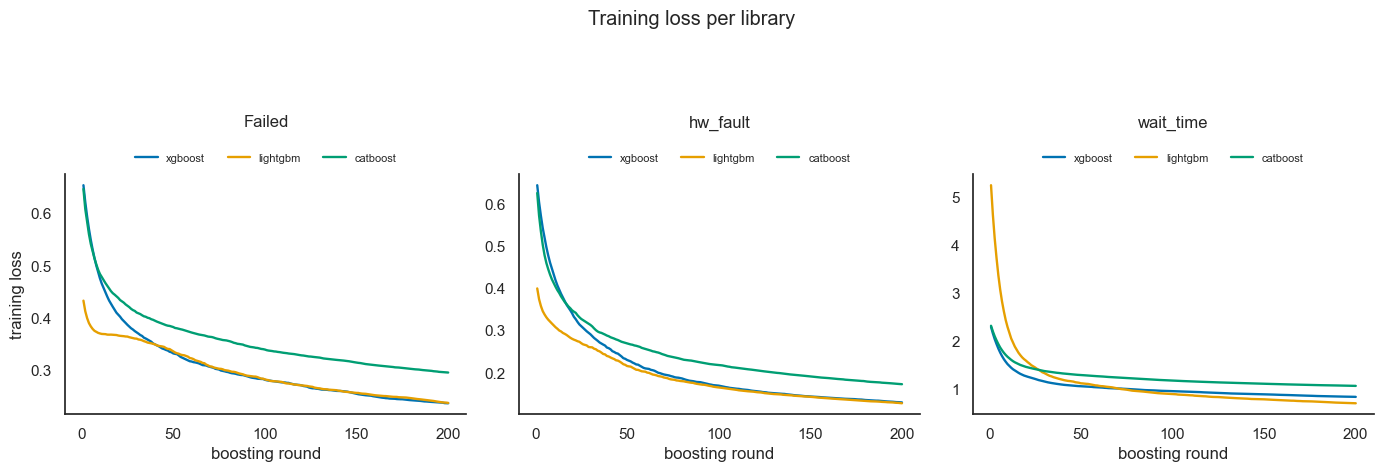

In [9]:
TASKS_L = ["Failed", "hw_fault", "wait_time"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, t in zip(axes, TASKS_L):
    for lib in MODEL_ORDER:
        c = loss_curves.get((t, lib))
        if c: ax.plot(range(1, len(c)+1), c, color=PAL_MODEL[lib], label=lib, lw=1.7)
    ax.set_title(t, pad=34); ax.set_xlabel("boosting round")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False, fontsize=8)
axes[0].set_ylabel("training loss")
sns.despine(); plt.suptitle("Training loss per library", y=1.12); plt.tight_layout(); plt.show()

### Confusion matrices (binary tasks at threshold 0.5, XGBoost, temporal test)

Row-normalized. `hw_fault` labels: 0 = Payload (Application+Submission), 1 = Hardware.

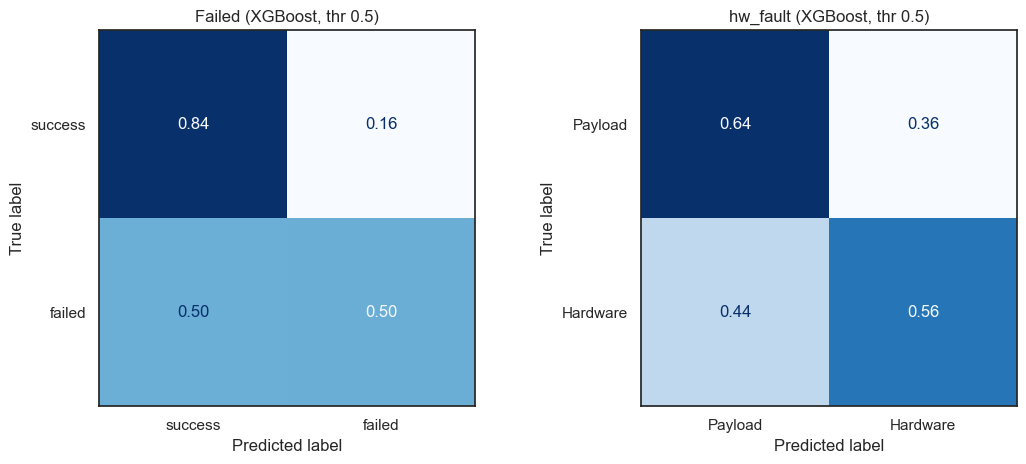

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
LABELS = {"Failed": ["success", "failed"], "hw_fault": ["Payload", "Hardware"]}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, t in zip(axes, ["Failed", "hw_fault"]):
    yte, p = pooled[(t, "xgboost")]
    cm = confusion_matrix(yte, (p >= 0.5).astype(int), labels=[0, 1], normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LABELS[t]).plot(ax=ax, cmap="Blues", colorbar=False,
                                                              values_format=".2f")
    ax.set_title(f"{t} (XGBoost, thr 0.5)")
plt.tight_layout(); plt.show()

### ROC curves — binary tasks, one curve per library

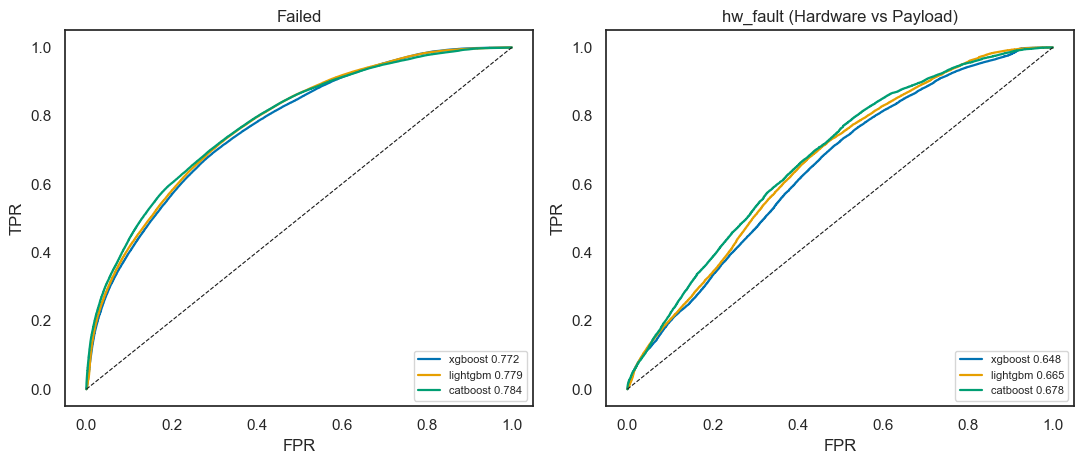

In [11]:
from sklearn.metrics import roc_curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, t in zip(axes, ["Failed", "hw_fault"]):
    for lib in MODEL_ORDER:
        yte, p = pooled[(t, lib)]; fpr, tpr, _ = roc_curve(yte, p)
        ax.plot(fpr, tpr, color=PAL_MODEL[lib], lw=1.6, label=f"{lib} {roc_auc_score(yte, p):.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(t + (" (Hardware vs Payload)" if t == "hw_fault" else ""))
    ax.legend(fontsize=8, loc="lower right"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
plt.tight_layout(); plt.show()

### Decision-threshold analysis (binary tasks, XGBoost)

Precision, recall, and F1 as the decision threshold sweeps 0→1; the dashed line marks the
F1-optimal threshold.

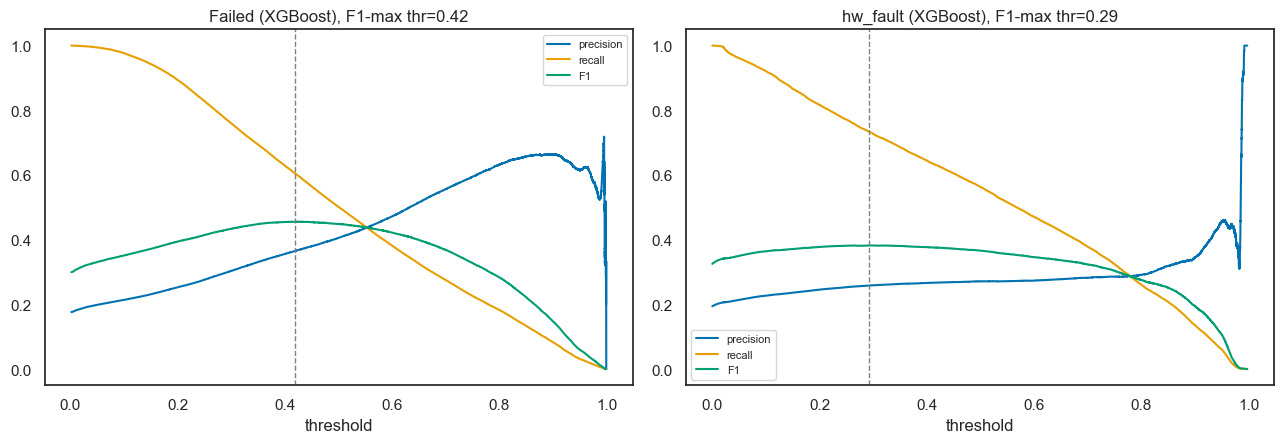

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, t in zip(axes, ["Failed", "hw_fault"]):
    thr, prec, rec, f1s = thr_curves[t]
    ax.plot(thr, prec, label="precision", color="#0072B2")
    ax.plot(thr, rec, label="recall", color="#E69F00")
    ax.plot(thr, f1s, label="F1", color="#009E73")
    bt = thr[int(np.argmax(f1s))]
    ax.axvline(bt, ls="--", color="gray", lw=1); ax.set_title(f"{t} (XGBoost), F1-max thr={bt:.2f}")
    ax.set_xlabel("threshold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Feature-importance matrices

Native gain importance per (task, library), normalized so each column sums to 100%. Split by
family so no cell is blank: the match-time heatmap spans the full feature set (including the
node/site trailing state), the submission-time heatmap spans submission features only.

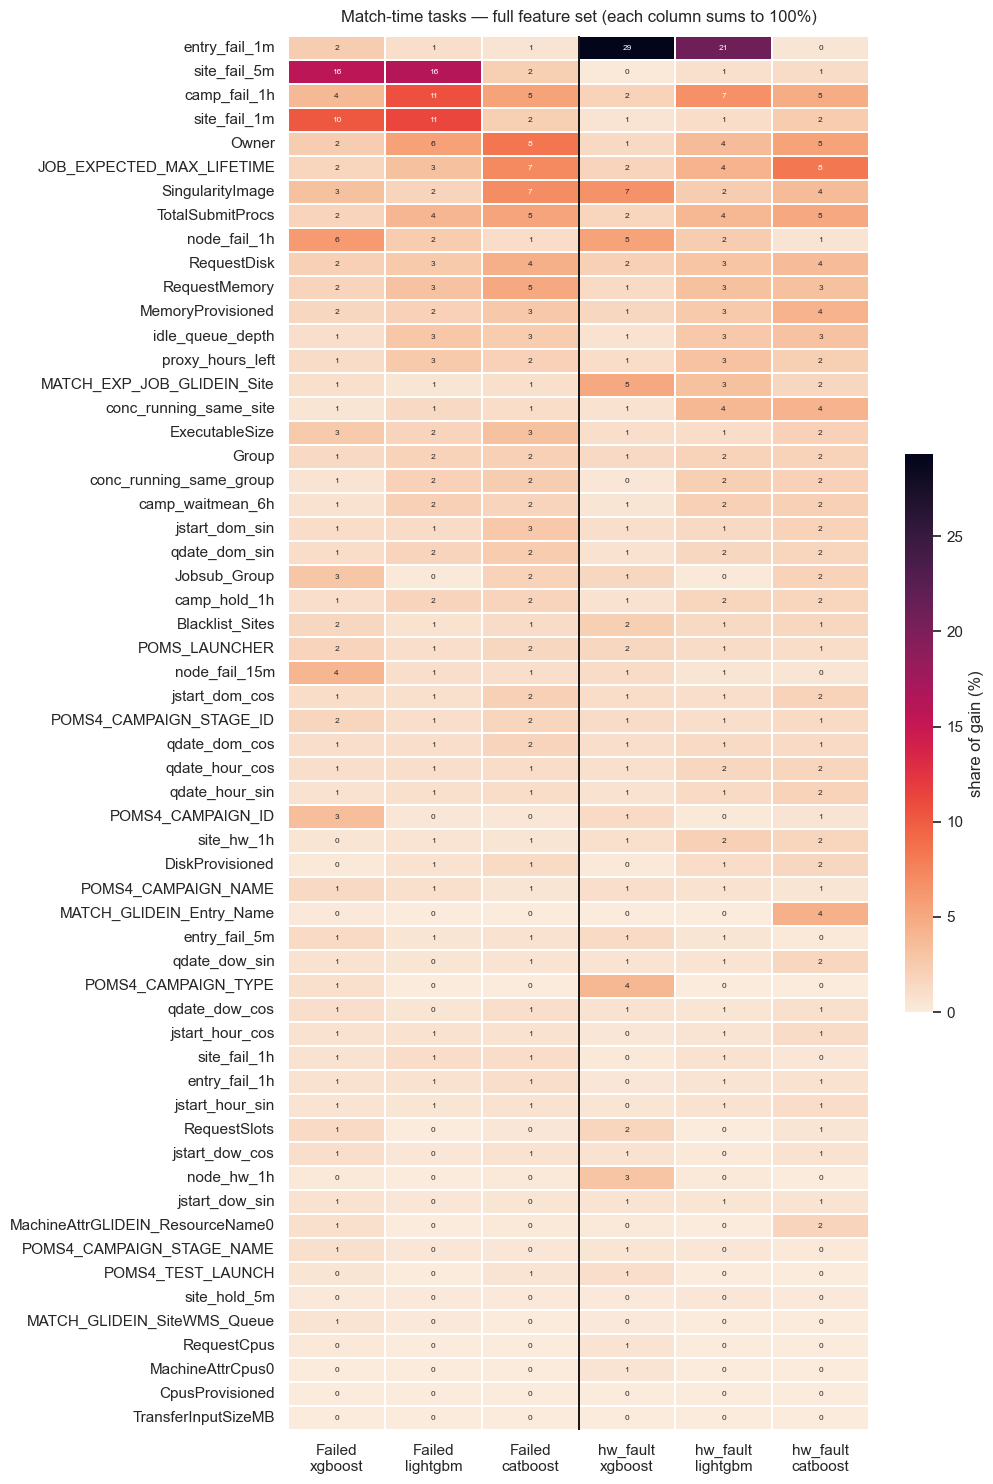

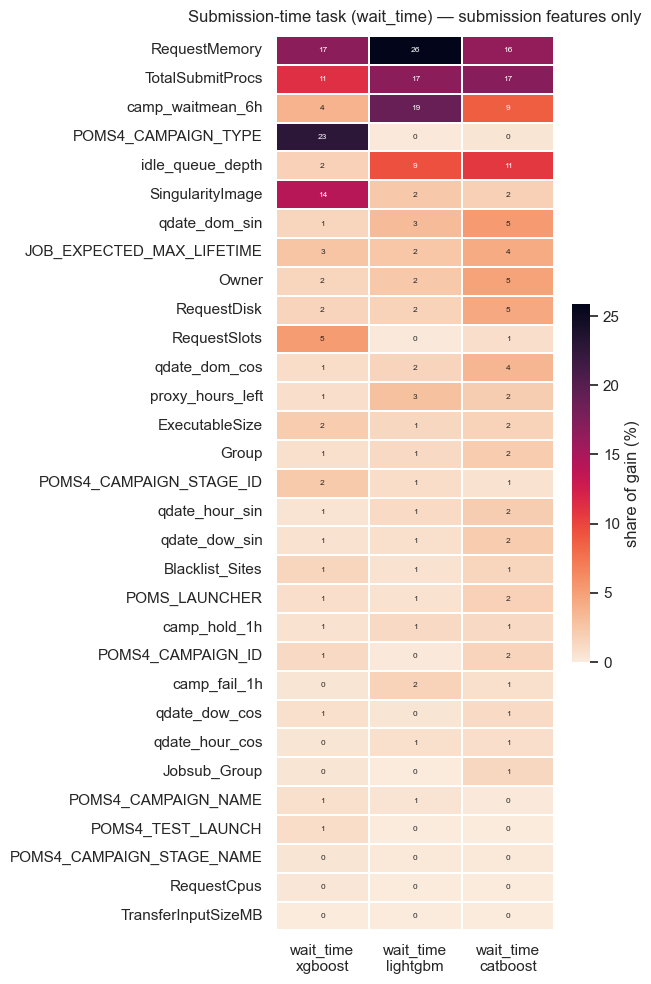

In [13]:
def imp_vec(lib, feats, base):
    v = np.zeros(len(feats))
    if lib == "xgboost":
        import xgboost as xgb; m = xgb.XGBClassifier()
        try: m.load_model(base + ".ubj")
        except Exception:
            m = xgb.XGBRegressor(); m.load_model(base + ".ubj")
        for k, val in m.get_booster().get_score(importance_type="gain").items():
            v[int(k[1:])] = val
    elif lib == "lightgbm":
        import lightgbm as lgb; b = lgb.Booster(model_file=base + ".txt")
        v = np.asarray(b.feature_importance("gain"), dtype=float)
    else:
        from catboost import CatBoost; m = CatBoost(); m.load_model(base + ".cbm")
        v = np.asarray(m.get_feature_importance(), dtype=float)
    s = v.sum(); return (v/s if s > 0 else v)

def imp_heatmap(task_names, feats, title, height):
    cols = {}
    for tname in task_names:
        for lib in MODEL_ORDER:
            cols[(tname, lib)] = imp_vec(lib, feats, f"{MODELS_DIR}/{lib}_{tname}")
    imp = pd.DataFrame(cols, index=feats)
    imp.columns = [f"{t}\n{l}" for t, l in cols]
    imp = imp.loc[imp.mean(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(2.6 + 1.3*len(imp.columns), height))
    sns.heatmap(imp*100, cmap="rocket_r", annot=True, fmt=".0f", annot_kws={"size": 6},
                cbar_kws={"label": "share of gain (%)", "shrink": 0.4}, linewidths=0.3,
                linecolor="white", ax=ax)
    for x in range(3, len(imp.columns), 3): ax.axvline(x, color="black", lw=1.3)
    ax.set_title(title, pad=10); ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

imp_heatmap(["Failed", "hw_fault"], MATCH_FEATS,
            "Match-time tasks — full feature set (each column sums to 100%)", 15)
imp_heatmap(["wait_time"], SUBMISSION_FEATS,
            "Submission-time task (wait_time) — submission features only", 10)

### Wait-time regression diagnostic (XGBoost)

Predicted vs. actual queue wait (log seconds); the diagonal is a perfect fit.

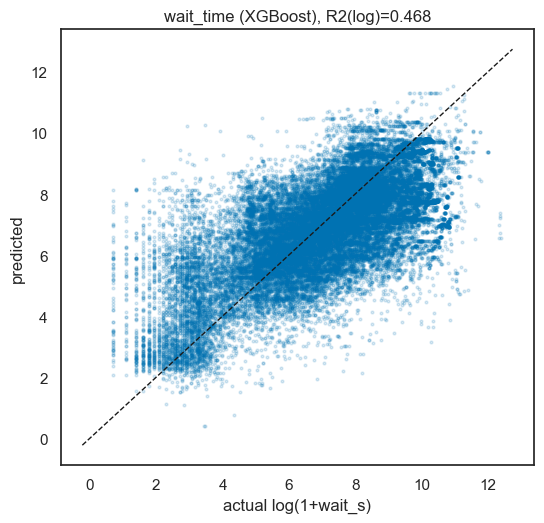

In [14]:
yte, pr = pooled[("wait_time", "xgboost")]
fig, ax = plt.subplots(figsize=(5.6, 5.4))
idx = np.random.default_rng(0).choice(len(yte), size=min(40000, len(yte)), replace=False)
ax.scatter(yte[idx], pr[idx], s=4, alpha=0.15, color="#0072B2")
lim = [min(yte.min(), pr.min()), max(yte.max(), pr.max())]
ax.plot(lim, lim, "k--", lw=1); ax.set_xlabel("actual log(1+wait_s)"); ax.set_ylabel("predicted")
ax.set_title(f"wait_time (XGBoost), R2(log)={r2_score(yte, pr):.3f}")
plt.tight_layout(); plt.show()

### Verdict (Hardware-vs-Payload, trimmed windows, proper match-attribute scoping)

Temporal split (train 1–4, test 5–6), 20% subset. Match tasks scoped to jobs with a non-null match
attribute (matched 97.7% — the real leak fix). `hw_fault` is defined over matched failures
(1.53M, of which 250k = 16% Hardware).

- **`failure_type` confusion is resolved by construction.** Application vs Submission was
  inseparable (68% of campaigns emit both), so we predict the separable **Hardware vs Payload**
  binary. hw_fault ROC 0.65–0.68 (CatBoost best), catching **56% of Hardware faults** at threshold
  0.5 (precision 0.28; the F1-max threshold ~0.3 lifts recall to 0.73). It leans on exactly the
  right features — `entry_fail_1m` (29%!), `MATCH_EXP_JOB_GLIDEIN_Site`, `node_fail_1h`,
  `node_hw_1h`, `site_hw_1h` — i.e. infrastructure health, which is what separates a systemic fault
  from a payload bug. The ceiling is modest because Hardware faults are only partly predictable: a
  healthy node can fail mid-job with no trailing signal.
- **`Failed` is now honest at ROC 0.77–0.78** (CatBoost 0.784), down from 0.80 — the match-attribute
  scoping removed the last 2.3% missingness leak. `site_fail_5m`/`site_fail_1m` dominate; recall is
  0.50 at threshold 0.5. Window trim confirmed: only 1m/5m (+1h anchor, node 15m/1h) survive; the
  15s/30s/15m/30m windows were dead weight and are gone.
- **`wait_time`: the honest metrics reframe it.** Median absolute error is **~16 min** (966 s,
  CatBoost), not the ~1h the raw MAE suggested — that MAE was inflated by the heavy tail (median
  wait 40 min, p99 40 h). Errors grow cleanly by regime: MAE 9 min for waits <10 min, 33 min for
  10 min–2 h, ~4 h for >2 h. Within-2× accuracy is 40–42%; R²(log) 0.47–0.50. The model gets the
  order of magnitude right most of the time; very short waits are proportionally the hardest.
  Drivers: `camp_waitmean_6h`, `idle_queue_depth`, requested resources.
- **Library choice**: CatBoost edges ahead on every task now (Failed 0.784, hw_fault 0.678,
  wait_time median-AE 966 s), though still within ~0.02–0.03.
- The **missingness audit** is now a standing guardrail; combined with dropping `JobStatus`,
  `LastHoldReasonCode`, `JobPrio`, `JobCurrentWaitTime`, month, `Drain`, and the null-match-attr
  jobs, every number here is what the model could actually achieve in deployment.

**For the paper:** the clean chain — each leak removed lowers the metric toward the truth (Failed
0.96 random → 0.84 campaign-aware → 0.80 with Drain → 0.78 leak-free-temporal) — is itself the
contribution: a leakage-audited, prediction-time-honest benchmark, with Hardware-vs-Payload as the
actionable, separable failure attribution.